CUP Pvalue: 0.2168556959012109
Inset p-value: 0.6683733276628843
Inset p-value: 0.19364039618065643


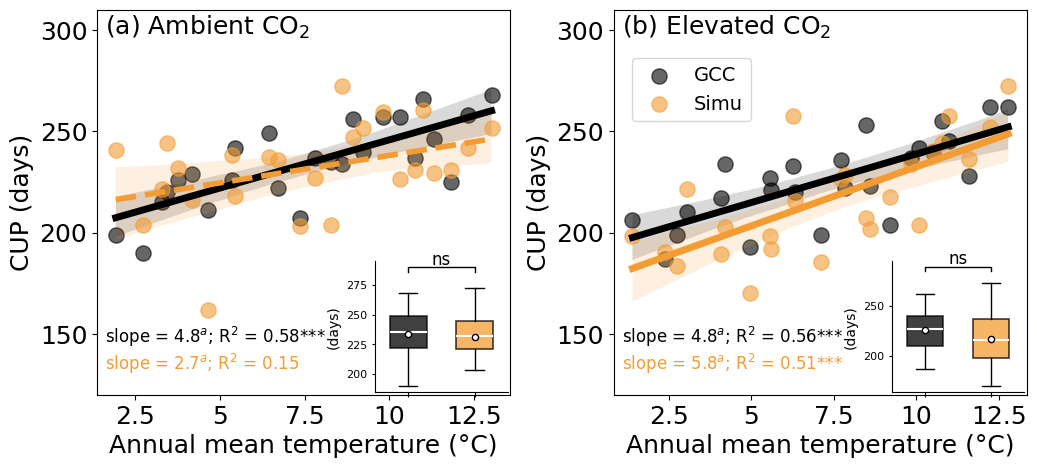

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy.stats import ttest_ind
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ---------------------------------------------------------------------
# Read data
# ---------------------------------------------------------------------
df_simu_eco = pd.read_excel(
    "../../data_results/2_results/2-3_gppmax_cup_6methods/calculated_GPPmax_CUP_ampFracs_10_20_30_25_thresholdScope_ecosystem.xlsx"
)

df_gcc_eco = pd.read_excel(
    "../../data_results/1_data_source/all_cup_cupstart_cupend.xlsx"
)

# df_gcc_eco = df_gcc_eco.rename()

# ---------------------------------------------------------------------
# Merge simulated and GCC data
# ---------------------------------------------------------------------
key_cols = [
    "plot", "year", "co2", "warming",
    "temp_mean", "temp_gs_mean", "temp_max", "temp_mean_anom",
]

# 只保留 CUP
df_simu_sub = df_simu_eco[
    key_cols + [
        "cup_whsM_25"
    ]
].rename(columns={
    "cup_whsM_25": "cup_simu"
})

df_gcc_sub = df_gcc_eco[
    key_cols + [
        "cup_ECO_pc"
    ]
].rename(columns={
    "cup_ECO_pc": "cup_gcc"
})

df_data_all = pd.merge(df_simu_sub, df_gcc_sub, on=key_cols, how="inner")

# ---------------------------------------------------------------------
# Keep study years
# ---------------------------------------------------------------------
df_data_all = df_data_all[
    (df_data_all["year"] >= 2017) & (df_data_all["year"] <= 2021)
].copy()

# ---------------------------------------------------------------------
# Plot settings
# ---------------------------------------------------------------------
# sns.set_style("white")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

xcol = "temp_mean_anom" #"temp_mean" # 
y_groups = [
    ("cup_gcc", "cup_simu", "CUP"),
]

ls_co2 = [0, 500]
ls_colors = ["k", "#F39C34"]   # GCC, Simu
ls_labels = ["GCC", "Simu"]

# ---------------------------------------------------------------------
# Inset configuration for each panel
# Format: (location, yaxis_side)
# ---------------------------------------------------------------------
inset_config = [
    [("lower right", "left")],
    [("lower right", "left")]
]

# ---------------------------------------------------------------------
# Text configuration for each panel
# Format:
# {
#   "gcc":  (x, y, ha, va),
#   "simu": (x, y, ha, va)
# }
# ---------------------------------------------------------------------
text_config = [
    [
        {"gcc": (0.02, 0.12, "left", "bottom"), "simu": (0.02, 0.05, "left", "bottom")},
    ],
    [
        {"gcc": (0.02, 0.12, "left", "bottom"), "simu": (0.02, 0.05, "left", "bottom")},
    ]
]

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def p_to_stars(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


def fit_linear_model(x, y):
    """
    Fit y ~ x and return regression results.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return {
            "slope": np.nan,
            "r2": np.nan,
            "p": np.nan,
            "linestyle": "--",
            "linewidth": 4,
        }

    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    slope = model.params[1]
    p_model = model.f_pvalue
    linestyle = "-" if p_model < 0.05 else "--"
    linewidth = 5 if p_model < 0.05 else 4

    return {
        "slope": slope,
        "r2": model.rsquared,
        "p": p_model,
        "linestyle": linestyle,
        "linewidth": linewidth
    }


def test_slope_difference(x, y1, y2):
    """
    Test whether slopes differ between two groups using an interaction model:
    value ~ temp * source

    If the interaction term is significant, slopes are significantly different.
    """
    x = np.asarray(x, dtype=float)
    y1 = np.asarray(y1, dtype=float)
    y2 = np.asarray(y2, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y1) & np.isfinite(y2)
    x = x[mask]
    y1 = y1[mask]
    y2 = y2[mask]

    if len(x) < 3:
        return np.nan

    df_long = pd.DataFrame({
        "temp": np.concatenate([x, x]),
        "value": np.concatenate([y1, y2]),
        "source": ["GCC"] * len(x) + ["Simu"] * len(x)
    })

    model = smf.ols("value ~ temp * source", data=df_long).fit()

    interaction_term = None
    for name in model.pvalues.index:
        if "temp:source" in name:
            interaction_term = name
            break

    if interaction_term is None:
        return np.nan

    return model.pvalues[interaction_term]


def add_inset_boxplot(ax, y1, y2, labels, colors, loc="lower right", yaxis_side="left"):
    """
    Add inset boxplot showing quartiles + median + mean marker.
    Also add significance stars.

    Parameters
    ----------
    ax : matplotlib axis
        Parent axis.
    y1, y2 : array-like
        Two datasets.
    labels : list
        Labels for the two groups.
    colors : list
        Colors for the two groups.
    loc : str
        Inset location.
    yaxis_side : str
        "left" or "right" for inset y-axis.
    """
    y1 = np.asarray(y1, dtype=float)
    y2 = np.asarray(y2, dtype=float)

    mask = np.isfinite(y1) & np.isfinite(y2)
    y1 = y1[mask]
    y2 = y2[mask]

    if len(y1) == 0:
        return

    ax_in = inset_axes(ax, width="32%", height="34%", loc=loc, borderpad=0.2)

    # Transparent background
    ax_in.set_facecolor("none")
    ax_in.patch.set_alpha(0)

    # Draw boxplots
    bp = ax_in.boxplot(
        [y1, y2],
        positions=[0, 1],
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="white", linewidth=1.5),
        boxprops=dict(linewidth=1.2),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0)
    )

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    # Add mean points
    means = [np.mean(y1), np.mean(y2)]
    ax_in.scatter([0, 1], means, marker="o", s=20, color="white", edgecolor="k", zorder=3)

    # Welch independent t-test
    if len(y1) >= 2:
        _, p_val = ttest_ind(y1, y2, nan_policy="omit", equal_var=False)
        sig = p_to_stars(p_val)
        print("Inset p-value:", p_val)
    else:
        sig = "NA"

    # Add significance bracket
    combined = np.concatenate([y1, y2])
    upper = np.max(combined)
    lower = np.min(combined)
    yrange = upper - lower
    if not np.isfinite(yrange) or yrange == 0:
        yrange = max(abs(upper), 1.0) * 0.2

    y_line = upper + yrange * 0.12
    y_text = upper + yrange * 0.15

    ax_in.plot(
        [0, 0, 1, 1],
        [y_line, y_line + yrange * 0.04, y_line + yrange * 0.04, y_line],
        color="k",
        lw=1
    )
    ax_in.text(0.5, y_text, sig, ha="center", va="bottom", fontsize=12)

    # X axis
    ax_in.set_xticks([0, 1])
    ax_in.set_xticklabels([])

    # Y axis side control
    if yaxis_side == "right":
        ax_in.yaxis.tick_right()
        ax_in.yaxis.set_label_position("right")
        ax_in.spines["left"].set_visible(False)
        ax_in.spines["right"].set_visible(True)
    else:
        ax_in.yaxis.tick_left()
        ax_in.yaxis.set_label_position("left")
        ax_in.spines["right"].set_visible(False)
        ax_in.spines["left"].set_visible(True)

    ax_in.spines["top"].set_visible(False)

    ax_in.tick_params(axis="y", labelsize=8, length=2)
    ax_in.set_ylabel("(days)", fontsize=10)


# ---------------------------------------------------------------------
# Print overall p-value for CUP
# ---------------------------------------------------------------------
for (ivar_gcc, ivar_gpp, ivar) in y_groups:
    y1 = df_data_all[ivar_gcc]
    y2 = df_data_all[ivar_gpp]
    _, pval = ttest_ind(y1, y2, nan_policy="omit", equal_var=False)
    print(ivar, "Pvalue:", pval)

# ---------------------------------------------------------------------
# Main plotting loop
# ---------------------------------------------------------------------
for irow in range(2):
    df_co2 = df_data_all[df_data_all["co2"] == ls_co2[irow]].copy()

    for icol in range(1):
        ax = axes[irow]
        ax.tick_params(axis="x", labelsize=18)
        ax.tick_params(axis="y", labelsize=18)

        gcc_col, simu_col, title_txt = y_groups[icol]

        ax.set_xlabel("Annual mean temperature (°C)", fontsize=18)
        ax.set_ylabel(title_txt + " (days)", fontsize=18)

        # Use matched data
        df_xy = df_co2[[xcol, gcc_col, simu_col]].dropna().copy()
        x = df_xy[xcol].to_numpy()
        y_gcc = df_xy[gcc_col].to_numpy()
        y_simu = df_xy[simu_col].to_numpy()

        # GCC regression
        res_gcc = fit_linear_model(x, y_gcc)
        sns.regplot(
            x=x,
            y=y_gcc,
            ax=ax,
            scatter_kws={
                "alpha": 0.6,
                "color": ls_colors[0],
                "s": 120
            },
            line_kws={
                "linestyle": res_gcc["linestyle"],
                "linewidth": res_gcc["linewidth"]
            },
            color=ls_colors[0],
            label=ls_labels[0]
        )

        # Simu regression
        res_simu = fit_linear_model(x, y_simu)
        sns.regplot(
            x=x,
            y=y_simu,
            ax=ax,
            scatter_kws={
                "alpha": 0.6,
                "color": ls_colors[1],
                "s": 120
            },
            line_kws={
                "linestyle": res_simu["linestyle"],
                "linewidth": res_simu["linewidth"]
            },
            color=ls_colors[1],
            label=ls_labels[1]
        )

        # Test slope difference
        p_slope_diff = test_slope_difference(x, y_gcc, y_simu)

        # Assign slope letters
        if pd.isna(p_slope_diff) or p_slope_diff >= 0.05:
            letter_gcc = "a"
            letter_simu = "a"
        else:
            letter_gcc = "a"
            letter_simu = "b"

        # Convert regression p-values to stars
        stars_gcc = p_to_stars(res_gcc["p"]) if pd.notna(res_gcc["p"]) and res_gcc["p"] < 0.05 else ""
        stars_simu = p_to_stars(res_simu["p"]) if pd.notna(res_simu["p"]) and res_simu["p"] < 0.05 else ""

        # Regression text
        txt_gcc = (
            f"slope = {res_gcc['slope']:.1f}$^{{{letter_gcc}}}$; "
            f"R$^2$ = {res_gcc['r2']:.2f}{stars_gcc}"
        )
        txt_simu = (
            f"slope = {res_simu['slope']:.1f}$^{{{letter_simu}}}$; "
            f"R$^2$ = {res_simu['r2']:.2f}{stars_simu}"
        )

        # Text configuration for this panel
        txt_cfg = text_config[irow][icol]

        x_gcc_txt, y_gcc_txt, ha_gcc, va_gcc = txt_cfg["gcc"]
        x_simu_txt, y_simu_txt, ha_simu, va_simu = txt_cfg["simu"]

        ax.text(
            x_gcc_txt, y_gcc_txt,
            txt_gcc,
            fontsize=12,
            ha=ha_gcc,
            va=va_gcc,
            transform=ax.transAxes,
            color=ls_colors[0]
        )

        ax.text(
            x_simu_txt, y_simu_txt,
            txt_simu,
            fontsize=12,
            ha=ha_simu,
            va=va_simu,
            transform=ax.transAxes,
            color=ls_colors[1]
        )

        # Inset configuration for this panel
        loc, yaxis_side = inset_config[irow][icol]

        # Add inset boxplot
        add_inset_boxplot(
            ax=ax,
            y1=y_gcc,
            y2=y_simu,
            labels=["GCC", "Simu"],
            colors=ls_colors,
            loc=loc,
            yaxis_side=yaxis_side
        )

# ---------------------------------------------------------------------
# Panel subtitles
# ---------------------------------------------------------------------
ls_subtitles = [
    "(a) Ambient CO$_2$",
    "(b) Elevated CO$_2$"
]

for idx_ax, ax in enumerate(np.atleast_1d(axes).flatten()):
    ax.text(
        0.02, 0.99,
        ls_subtitles[idx_ax],
        fontsize=18,
        ha="left",
        va="top",
        transform=ax.transAxes
    )

# ---------------------------------------------------------------------
# Optional y-limits
# ---------------------------------------------------------------------
axes[0].set_ylim(120, 310)
axes[1].set_ylim(120, 310)

for i in range(2):
    axes[i].set_xticks([2.5, 5, 7.5, 10, 12.5])
    axes[i].set_xticklabels([2.5, 5, 7.5, 10, 12.5])

# for i in range(2):
#     axes[i].set_xticks([5, 7.5, 10, 12.5, 15])
#     axes[i].set_xticklabels([5, 7.5, 10, 12.5, 15])

# ---------------------------------------------------------------------
# Show legend only once
# ---------------------------------------------------------------------
axes[1].legend(
    fontsize=14,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.9),
)

plt.subplots_adjust(hspace=0.25, wspace=0.25)
plt.show()